# 🍽️ SmartMealLog — Nutrition ML Pipeline

---

## 1. 🔧 Environment Setup


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import re
import warnings
from datetime import datetime
from pathlib import Path

# ── Scientific computing ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn: preprocessing ────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import KNNImputer

# ── Sklearn: models ───────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
# ── Gradient boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Global config ─────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('=' * 70)
print('SMARTMEALLOG — NUTRITION ML PIPELINE')
print('=' * 70)
print(f'Run : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
import sklearn
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | '
      f'sklearn {sklearn.__version__} | XGBoost {xgb.__version__} | '
      f'LightGBM {lgb.__version__}')
print()

SMARTMEALLOG — NUTRITION ML PIPELINE
Run : 2026-02-18 13:10:57
NumPy 2.4.0 | Pandas 2.3.3 | sklearn 1.8.0 | XGBoost 3.1.3 | LightGBM 4.6.0



---

## 2. ⚙️ Configuration — The Only Cell You Need to Edit



In [ ]:
USDA_DIR      = Path('datasets')              
NUTRITION_CSV = Path('datasets/nutrition.csv')  
# ─────────────────────────────────────────────────────────────────────────────

# ── 166 food classes (image-recognition model) ───────────────────────────────
ALL_FOOD_CLASSES = [
    'apple_fuji','apple_golden','apple_granny','apple_ligol','apple_pie',
    'apple_red_delicious','apple_spartan','apricot_armenian','apricot_jerdel',
    'avocado_hass','avocado_zutano','baby_back_ribs','baklava','banana_mini',
    'banana_yellow','beef_carpaccio','beef_tartare','beet_round','beet_salad',
    'beignets','bibimbap','bread_pudding','breakfast_burrito','bruschetta',
    'cabbage_broccoli','cabbage_cauliflower','cabbage_peking','cabbage_white',
    'caesar_salad','cannoli','caprese_salad','carrot_cake','carrot_carrot',
    'ceviche','cheese_plate','cheesecake','chicken_curry','chicken_quesadilla',
    'chicken_wings','chocolate_cake','chocolate_mousse','churros','clam_chowder',
    'club_sandwich','corn_corn','crab_cakes','creme_brulee','croque_madame',
    'cucumber_long','cucumber_medium','cup_cakes','daikon_daikon','deviled_eggs',
    'donuts','dumplings','edamame','eggs_benedict','escargots','falafel',
    'filet_mignon','fish_and_chips','foie_gras','french_fries','french_onion_soup',
    'french_toast','fried_calamari','fried_rice','frozen_yogurt','garlic_bread',
    'garlic_garlic','gnocchi','grape_black','grape_green','grape_pink',
    'grapefruit_grapefruit','greek_salad','grilled_cheese_sandwich','grilled_salmon',
    'guacamole','gyoza','hamburger','hot_and_sour_soup','hot_dog','huevos_rancheros',
    'hummus','ice_cream','kiwi_kiwi','lasagna','lemon_orange','lemon_yellow',
    'lime_lime','lobster_bisque','lobster_roll_sandwich','macaroni_and_cheese',
    'macarons','mango_mango','melon_torpeda','miso_soup','mussels','nachos',
    'nectarine_flat','nectarine_round','omelette','onion_purple','onion_rings',
    'onion_white','orange_orange','oysters','pad_thai','paella','pancakes',
    'panna_cotta','pear_conference','pear_williams_rouge','peking_duck',
    'pepper_chili','pepper_sweet_elonged','pepper_sweet_green','pepper_sweet_red',
    'pepper_sweet_yellow','pho','pizza','plum_pink','plum_purple',
    'pomegranate_pomegranate','pomelo_pomelo','pork_chop','potato_pink',
    'potato_yellow','poutine','prime_rib','pulled_pork_sandwich','pumpkin_elonged',
    'raddish_elonged','raddish_round','ramen','ravioli','red_velvet_cake',
    'risotto','salad_green','samosa','sashimi','scallops','seaweed_salad',
    'shrimp_and_grits','spaghetti_bolognese','spaghetti_carbonara','spring_rolls',
    'steak','strawberry_shortcake','sushi','tacos','takoyaki','tangerine_tangerine',
    'tiramisu','tomato_bull_heart','tomato_cherry_red','tomato_cherry_yellow',
    'tomato_pink','tomato_slivka','tomato_yellow','tuna_tartare','waffles',
    'watermelon_elonged','zucchini_green','zucchini_white',
]

# ── 18 USDA nutrient IDs → column names ──────────────────────────────────────
NUTRIENT_MAP = {
    'calories':        1008,
    'protein_g':       1003,
    'fat_g':           1004,
    'carbs_g':         1005,
    'fiber_g':         1079,
    'sugar_g':         2000,
    'sodium_mg':       1093,
    'saturated_fat_g': 1258,
    'trans_fat_g':     1257,
    'cholesterol_mg':  1253,
    'potassium_mg':    1092,
    'calcium_mg':      1087,
    'iron_mg':         1089,
    'vitamin_c_mg':    1162,
    'vitamin_d_ug':    1114,
    'vitamin_a_ug':    1106,
    'added_sugar_g':   1235,
    'water_g':         1051,
}
TARGET_NIDS  = set(NUTRIENT_MAP.values())
NUTRIENT_COLS = list(NUTRIENT_MAP.keys())

# ── Manual FDC ID overrides for foods smart_clean_label cannot resolve ──────
# Covers: misspellings, non-USDA dishes, too-generic fallbacks.
# Format: food_label → fdc_id (Foundation/SR Legacy preferred)
# To find an FDC ID: https://fdc.nal.usda.gov/food-search
MANUAL_OVERRIDES = {
    # ── Spelling fix: our labels say 'raddish', USDA says 'radish' ────────
    'raddish_elonged':   169276,   # Radish, raw  (SR Legacy)
    'raddish_round':     169276,   # Radish, raw  (same base food)
    # ── Too-generic fallbacks — explicit beats accidental match ───────────
    'salad_green':       168462,   # Lettuce, green leaf, raw  (Foundation)
    'baby_back_ribs':    167875,   # Pork, backribs, raw
    'cup_cakes':         174928,   # Cake, cupcake (SR Legacy)
    'pad_thai':          172934,   # Restaurant, Chinese, noodles (Survey — closest)
    'spring_rolls':      173575,   # Spring rolls, chicken (Survey)
    'hot_dog':           172913,   # Frankfurter, beef (SR Legacy)
    # ── Dishes not in USDA — use Survey 'as consumed' closest match ───────
    'poutine':           172919,   # French fries with gravy (Survey — closest)
    'bibimbap':          172935,   # Restaurant, Korean (Survey)
    'takoyaki':          174991,   # Fish cake (Survey — closest available)
    # ── red_velvet_cake: first query 'red velvet cake' is fine ────────────
    # Only the fallback 'red' is bad — handled by override below
    'red_velvet_cake':   174928,   # Cake, chocolate (SR Legacy — closest)
}

print(f'Food classes  : {len(ALL_FOOD_CLASSES)}')
print(f'Nutrient cols : {len(NUTRIENT_MAP)}')
print(f'USDA dir      : {USDA_DIR}  (exists: {USDA_DIR.exists()})')
print(f'nutrition.csv : {NUTRITION_CSV}  (exists: {NUTRITION_CSV.exists()})')


Food classes  : 166
Nutrient cols : 18
USDA dir      : datasets  (exists: True)
nutrition.csv : datasets\nutrition.csv  (exists: True)


---

## 3. 🔍 Smart USDA Food Matching


---

### ⭐ Quality Scoring — Getting the *Best* USDA Match

When multiple entries match a query (e.g. "apple" returns hundreds of results), the best one is chosen by a scoring system that mirrors USDA's own quality ranking:

| Tier | Source | What it means |
|---|---|---|
| ⭐⭐⭐⭐ Foundation | Multi-lab analytical chemistry | Most complete, highest confidence |
| ⭐⭐⭐ SR Legacy | USDA Standard Reference | Long-standing reference data, well-curated |
| ⭐⭐ Survey (FNDDS) | What people actually eat | Realistic portions, good for apps |
| ⭐ Branded | Manufacturer-reported | Least verified, used as last resort |

The scorer also:
- **Prefers raw over processed** (raw ingredients score higher than frozen or canned)
- **Prefers shorter descriptions** (to avoid accidentally matching very specific prepared dishes)
- **Rewards whole-word matches** over partial matches

> 🔍 **Full transparency:** Every match is recorded in `food_fdc_mapping.json` with the exact query used and all queries that were tried. You can audit the entire process after running.


In [ ]:
_COLOUR_SUFFIXES = frozenset({
    'red','green','yellow','orange','black','white','pink','purple',
    'brown','golden','blue','silver','dark','light','rouge',
})
_SHAPE_SUFFIXES = frozenset({
    'elonged','round','long','flat','mini','small','large','medium',
    'torpedo','bull_heart','cherry','slivka',
})

# Spelling corrections — our food labels vs USDA spelling
_SPELLING_FIX = {
    'raddish': 'radish',   # our labels use double-d; USDA uses single-d
}
_DROP_SUFFIXES = _COLOUR_SUFFIXES | _SHAPE_SUFFIXES

# Partial variety names our labels use → their full USDA-recognisable names
# Empty string means: no USDA entry for this variety → drop and use base word
_VARIETY_ALIASES = {
    'granny':        'granny smith',
    'delicious':     'red delicious',
    'fuji':          'fuji',
    'spartan':       '',       # regional variety — not in USDA, fall back to 'apple'
    'ligol':         '',       # Polish variety  — not in USDA, fall back to 'apple'
    'hass':          'hass',   # USDA has 'avocados, hass'
    'zutano':        '',       # rare variety    — fall back to 'avocado'
    'armenian':      '',       # regional        — fall back to 'apricot'
    'jerdel':        '',       # regional        — fall back to 'apricot'
    'conference':    '',       # pear variety    — fall back to 'pear'
    'williams':      'williams',
    'torpeda':       '',       # melon shape     — fall back to 'melon'
    'peking':        '',       # handled by USDA_REORDER below
}

# Labels where word ORDER must change to match USDA naming conventions
# Format: (base_word, trigger_word) → query_template
# {colour} is replaced by any colour word found in the label
_USDA_REORDER = [
    ('pepper',  'sweet',  '{colour} pepper, sweet'),
    ('pepper',  'chili',  'chili pepper'),
    ('cabbage', 'peking', 'cabbage, chinese'),
    ('cabbage', 'broccoli', 'broccoli'),
    ('cabbage', 'cauliflower', 'cauliflower'),
    ('garlic',  'garlic', 'garlic'),          # garlic_garlic → 'garlic'
]


def smart_clean_label(label: str) -> list:
    """
    Convert a snake_case food label into a ranked cascade of USDA search queries.

    Returns a list of query strings, from most-specific to least-specific.
    The caller tries each in order and stops at the first match.

    Examples
    --------
    >>> smart_clean_label('kiwi_kiwi')
    ['kiwi']
    >>> smart_clean_label('pepper_sweet_green')
    ['green pepper, sweet', 'pepper']
    >>> smart_clean_label('apple_granny')
    ['apple granny smith', 'apple']
    >>> smart_clean_label('watermelon_elonged')
    ['watermelon']
    >>> smart_clean_label('apple_ligol')
    ['apple']
    """
    parts = label.lower().split('_')

    # ── Step 1: Remove exact duplicate words & fix spelling ──────────────────
    # 'kiwi_kiwi' → ['kiwi'],  'garlic_garlic' → ['garlic']
    # 'raddish'   → 'radish'   (spelling correction for USDA compatibility)
    seen, deduped = set(), []
    for p in parts:
        p = _SPELLING_FIX.get(p, p)   # apply spelling corrections
        if p not in seen:
            deduped.append(p)
            seen.add(p)
    parts = deduped

    base      = parts[0]
    modifiers = parts[1:]

    # ── Step 2: Check USDA reorder rules FIRST (highest priority) ────────────
    # Handles 'pepper_sweet_green' → 'green pepper, sweet'
    colour_in_label = next(
        (m for m in modifiers if m in _COLOUR_SUFFIXES), ''
    )
    for rule_base, rule_trigger, template in _USDA_REORDER:
        if base == rule_base and rule_trigger in modifiers:
            reordered = template.format(colour=colour_in_label).strip(', ')
            # Remove double spaces
            reordered = ' '.join(reordered.split())
            return _dedupe_list([reordered, base])

    # ── Step 3: Remove pure colour/shape suffixes (USDA never uses them) ─────
    # 'watermelon_elonged' → base='watermelon', drop 'elonged'
    # 'banana_yellow' → base='banana', drop 'yellow'
    meaningful = [m for m in modifiers if m not in _DROP_SUFFIXES]

    # ── Step 4: Apply variety aliases ─────────────────────────────────────────
    # 'granny' → 'granny smith'  |  'ligol' → '' (unknown variety → drop)
    resolved, has_unknown = [], False
    for m in meaningful:
        if m in _VARIETY_ALIASES:
            alias = _VARIETY_ALIASES[m]
            if alias:
                resolved.append(alias)  # use full alias
            else:
                has_unknown = True      # unknown variety → only fallback to base
        else:
            resolved.append(m)

    # ── Step 5: Build candidate queries (most → least specific) ───────────────
    candidates = []

    if not has_unknown and resolved:
        # Full query: 'apple granny smith'
        candidates.append(base + ' ' + ' '.join(resolved))

        # Medium query: base + first modifier only (e.g. 'pear williams')
        if len(resolved) > 1:
            candidates.append(base + ' ' + resolved[0])

    # Always include base word alone as final fallback
    candidates.append(base)

    return _dedupe_list(candidates)


def _dedupe_list(lst: list) -> list:
    """Remove duplicates from a list while preserving order."""
    seen, out = set(), []
    for x in lst:
        x = x.strip()
        if x and x not in seen:
            out.append(x)
            seen.add(x)
    return out


# ── Quick self-test (runs every time cell executes) ───────────────────────────
_TESTS = [
    ('kiwi_kiwi',              'kiwi'),
    ('mango_mango',            'mango'),
    ('watermelon_elonged',     'watermelon'),
    ('banana_yellow',          'banana'),
    ('grape_black',            'grape'),
    ('apple_granny',           'apple granny smith'),
    ('apple_ligol',            'apple'),
    ('apple_spartan',          'apple'),
    ('avocado_hass',           'avocado hass'),
    ('avocado_zutano',         'avocado'),
    ('pepper_sweet_green',     'green pepper, sweet'),
    ('pepper_sweet_red',       'red pepper, sweet'),
    ('pepper_chili',           'chili pepper'),
    ('cabbage_peking',         'cabbage, chinese'),
    ('cabbage_broccoli',       'broccoli'),
    ('garlic_garlic',          'garlic'),
    ('apricot_armenian',       'apricot'),
    ('pear_conference',        'pear'),
    ('pear_williams_rouge',    'pear williams'),
]
failed = []
for lbl, expected in _TESTS:
    queries = smart_clean_label(lbl)
    if expected not in queries:
        failed.append(f"  FAIL  {lbl!r:<30} got {queries}, expected '{expected}' in it")

if failed:
    print('⚠️  smart_clean_label self-test FAILURES:')
    print('\n'.join(failed))
else:
    print(f'✅  smart_clean_label: all {len(_TESTS)} self-tests passed')
    print()
    print('  Example outputs:')
    for lbl in ['kiwi_kiwi','apple_granny','apple_ligol','pepper_sweet_green',
                'watermelon_elonged','avocado_hass','cabbage_broccoli']:
        print(f'  {lbl:<30} → {smart_clean_label(lbl)}')


✅  smart_clean_label: all 19 self-tests passed

  Example outputs:
  kiwi_kiwi                      → ['kiwi']
  apple_granny                   → ['apple granny smith', 'apple']
  apple_ligol                    → ['apple']
  pepper_sweet_green             → ['green pepper, sweet', 'pepper']
  watermelon_elonged             → ['watermelon']
  avocado_hass                   → ['avocado hass', 'avocado']
  cabbage_broccoli               → ['broccoli', 'cabbage']


### 🏗️ `build_food_mapping()` — Putting It All Together



In [4]:
# ── USDA data quality tier weights ───────────────────────────────────────────
# Foundation > SR Legacy > Survey (FNDDS) > Branded
# This mirrors USDA's own quality ranking:
#   Foundation: most analytically complete, multi-lab verified
#   SR Legacy:  long-standing reference data, well-curated
#   Survey:     food as consumed, good for portions
#   Branded:    manufacturer-reported, least verified
_DATA_TYPE_PRIORITY = {
    'foundation_food':   4,
    'sr_legacy_food':    3,
    'survey_fndds_food': 2,
    'branded_food':      1,
}


def _score_candidate(desc: str, keywords: list, data_type: str) -> float:
    """Score a USDA food entry against search keywords.

    Combines:
    - Data quality tier  (foundation > sr_legacy > survey > branded)
    - Exact word matches (whole-word regex, weighted highest)
    - Substring matches  (partial, weighted lower)
    - 'raw' preference   (raw ingredients preferred over prepared)
    - Length penalty     (prefer shorter, more specific descriptions)
    """
    desc_l = desc.lower()
    score  = _DATA_TYPE_PRIORITY.get(data_type, 0) * 200  # tier dominates

    score -= len(desc_l) * 0.05          # prefer concise entries

    if 'raw' in desc_l:     score += 60  # raw > cooked for ingredients
    if 'whole' in desc_l:   score += 20
    if 'dried' in desc_l:   score -= 10  # prefer fresh over dried
    if 'frozen' in desc_l:  score -= 15
    if 'canned' in desc_l:  score -= 20

    for kw in keywords:
        if re.search(rf'\b{re.escape(kw)}\b', desc_l):
            score += 120   # exact whole-word match
        elif kw in desc_l:
            score += 40    # substring match

    return score


def _search_food_df(query: str, food_df: pd.DataFrame) -> tuple | None:
    """Search food_df for the best match to a query string.

    Returns (fdc_id, description, data_type) or None.
    The search tries all keywords together, then falls back to
    the first keyword alone if no multi-keyword match is found.
    """
    keywords = query.split()
    if not keywords:
        return None

    # Try all keywords together first (most selective)
    mask = food_df['description'].str.contains(
        keywords[0], case=False, na=False, regex=False
    )
    for kw in keywords[1:]:
        mask &= food_df['description'].str.contains(
            kw, case=False, na=False, regex=False
        )
    matches = food_df[mask].copy()

    # Fallback: first keyword only
    if matches.empty:
        mask = food_df['description'].str.contains(
            keywords[0], case=False, na=False, regex=False
        )
        matches = food_df[mask].copy()

    if matches.empty:
        return None

    matches['_score'] = matches.apply(
        lambda r: _score_candidate(r['description'], keywords, r['data_type']),
        axis=1
    )
    best = matches.nlargest(1, '_score').iloc[0]
    return int(best['fdc_id']), best['description'], best['data_type']


def build_food_mapping(usda_dir: Path) -> dict:
    """Map all 166 food classes to USDA FDC IDs automatically.

    Algorithm:
    1. Generate a cascade of queries via smart_clean_label()
    2. Try each query in order (most specific → least specific)
    3. Score all candidates using data-type tier + keyword matching
    4. Select the highest-scoring match
    5. Report any foods that could not be matched at all

    No manual FDC ID overrides required.
    """
    print('Loading food.csv ...')
    food_df = pd.read_csv(
        usda_dir / 'food.csv',
        usecols=['fdc_id', 'description', 'data_type'],
        low_memory=False
    )
    food_df['description'] = food_df['description'].astype(str)

    total = len(food_df)
    by_type = food_df['data_type'].value_counts().to_dict()
    print(f'  Total USDA entries : {total:,}')
    for dt, n in sorted(by_type.items(), key=lambda x: -x[1]):
        tier = _DATA_TYPE_PRIORITY.get(dt, 0)
        print(f'    Tier {tier}  {dt:<25}: {n:,}')

    mapping    = {}
    no_match   = []
    query_log  = {}   # {label: queries_tried} — useful for debugging

    for label in ALL_FOOD_CLASSES:
        # Generate cascade of queries from most to least specific
        queries = smart_clean_label(label)
        query_log[label] = queries

        matched = False
        for query in queries:
            result = _search_food_df(query, food_df)
            if result:
                fdc_id, desc, dtype = result
                mapping[label] = {
                    'fdc_id':      fdc_id,
                    'description': desc,
                    'data_type':   dtype,
                    'query_used':  query,      # for transparency / auditability
                    'queries_tried': queries,  # full cascade for debugging
                }
                matched = True
                break

        if not matched:
            no_match.append(label)

    # ── Summary ───────────────────────────────────────────────────────────────
    tier_counts = {}
    for info in mapping.values():
        t = info['data_type']
        tier_counts[t] = tier_counts.get(t, 0) + 1

    print(f'\n  Mapped   : {len(mapping)} / {len(ALL_FOOD_CLASSES)} foods')
    print(f'  Quality breakdown:')
    for dt, n in sorted(tier_counts.items(),
                        key=lambda x: -_DATA_TYPE_PRIORITY.get(x[0], 0)):
        tier = _DATA_TYPE_PRIORITY.get(dt, 0)
        print(f'    Tier {tier} ({dt}) : {n} foods')

    if no_match:
        print(f'\n  ⚠️  Could not match {len(no_match)} foods:')
        for f in no_match:
            print(f'    - {f}  (tried: {query_log[f]})')
    else:
        print(f'\n  ✅ All {len(ALL_FOOD_CLASSES)} food classes matched automatically.')

    # ── FIX P3: Apply manual overrides for known bad/missing matches ─────────
    # Fetch descriptions for overridden FDC IDs from food_df for auditability
    override_count = 0
    for label, fdc_id in MANUAL_OVERRIDES.items():
        desc_rows = food_df[food_df['fdc_id'] == fdc_id]
        if desc_rows.empty:
            print(f'  ⚠️  Override FDC ID {fdc_id} for {label!r} not found in food.csv — skipping')
            continue
        desc = desc_rows.iloc[0]['description']
        dtype = desc_rows.iloc[0]['data_type']
        was_auto = mapping.get(label, {}).get('description', 'unmatched')
        mapping[label] = {
            'fdc_id':        int(fdc_id),
            'description':   desc,
            'data_type':     dtype,
            'query_used':    f'manual_override (fdc_id={fdc_id})',
            'queries_tried': query_log.get(label, []),
        }
        override_count += 1
        print(f'  ↩  Override {label:<30} → "{desc}"  (was: "{was_auto}")')
    if override_count:
        print(f'\n  ✓ Applied {override_count} manual overrides.')

    return mapping


mapping = build_food_mapping(USDA_DIR)

# Save mapping for inspection / auditing
with open('food_fdc_mapping.json', 'w') as fh:
    json.dump(mapping, fh, indent=2)
print('\n✓ Saved: food_fdc_mapping.json')
print('  Open this file to audit every match — query used and data type shown.')


Loading food.csv ...
  Total USDA entries : 2,064,912
    Tier 1  branded_food             : 1,977,398
    Tier 0  sub_sample_food          : 62,022
    Tier 3  sr_legacy_food           : 7,793
    Tier 0  market_acquistion        : 7,215
    Tier 2  survey_fndds_food        : 5,432
    Tier 0  sample_food              : 3,717
    Tier 0  agricultural_acquisition : 810
    Tier 4  foundation_food          : 411
    Tier 0  experimental_food        : 114

  Mapped   : 165 / 166 foods
  Quality breakdown:
    Tier 4 (foundation_food) : 57 foods
    Tier 3 (sr_legacy_food) : 46 foods
    Tier 2 (survey_fndds_food) : 29 foods
    Tier 1 (branded_food) : 33 foods

  ⚠️  Could not match 1 foods:
    - takoyaki  (tried: ['takoyaki'])
  ↩  Override raddish_elonged                → "Radishes, raw"  (was: "Radish seeds, sprouted, raw")
  ↩  Override raddish_round                  → "Radishes, raw"  (was: "Radish seeds, sprouted, raw")
  ↩  Override salad_green                    → "Spinach, raw"

---

## 4. 🧪 Extracting 18 Nutrients from the USDA Database

In [5]:
def extract_nutrients(mapping: dict, usda_dir: Path) -> pd.DataFrame:
    """Extract 18 nutritional values per food from food_nutrient.csv."""
    fdc_ids_needed = {m['fdc_id'] for m in mapping.values()}
    print(f'Scanning food_nutrient.csv for {len(fdc_ids_needed)} FDC IDs ...')

    nutrient_store = {}
    chunk_count = 0
    rows_kept   = 0

    for chunk in pd.read_csv(
        usda_dir / 'food_nutrient.csv',
        usecols=['fdc_id', 'nutrient_id', 'amount'],
        chunksize=2_000_000,
        dtype={'fdc_id': 'Int64', 'nutrient_id': 'Int64', 'amount': 'float32'},
        low_memory=False
    ):
        chunk_count += 1
        relevant = chunk[chunk['fdc_id'].isin(fdc_ids_needed) & chunk['nutrient_id'].isin(TARGET_NIDS)]
        rows_kept += len(relevant)

        for row in relevant.itertuples(index=False):
            fid = int(row.fdc_id)
            nid = int(row.nutrient_id)
            if fid not in nutrient_store: nutrient_store[fid] = {}
            nutrient_store[fid][nid] = float(row.amount)

    # Assemble rows
    rows = []
    for label, info in mapping.items():
        fid  = info['fdc_id']
        nuts = nutrient_store.get(fid, {})
        row  = {'food_name': label, 'fdc_id': fid, 'description': info['description']}
        for col_name, nid in NUTRIENT_MAP.items():
            row[col_name] = nuts.get(nid, np.nan)
        rows.append(row)

    base_df = pd.DataFrame(rows)

    # KNN Imputation
    print('\nApplying within-category KNN imputation...')
    base_df['_category'] = base_df['food_name'].apply(_categorize)
    for cat in base_df['_category'].unique():
        mask = base_df['_category'] == cat
        sub  = base_df.loc[mask, NUTRIENT_COLS]
        
        # Only attempt if there are missing values and at least 2 items
        if sub.isnull().sum().sum() > 0 and len(sub) > 1:
            # IMPORTANT FIX: KNNImputer drops columns that are all NaN.
            # We filter those out first so shapes stay (32, 18)
            cols_to_impute = sub.columns[sub.notnull().any()].tolist()
            
            if cols_to_impute:
                n_neighbours = max(1, min(5, len(sub) - 1))
                imputer = KNNImputer(n_neighbors=n_neighbours)
                
                # Impute ONLY the non-empty columns
                imputed_data = imputer.fit_transform(sub[cols_to_impute])
                
                # Assign back safely
                base_df.loc[mask, cols_to_impute] = imputed_data
                print(f'    {cat}: imputed {len(cols_to_impute)} cols with k={n_neighbours}')
        elif len(sub) <= 1:
             print(f'    {cat}: skipping (too few items)')

    base_df = base_df.drop(columns=['_category'])
    base_df.to_csv('usda_base_values_per100g.csv', index=False)
    print('\n✓ Saved: usda_base_values_per100g.csv')
    return base_df


def _categorize(food_name: str) -> str:
    """Rule-based food categoriser (6 categories)."""
    n = food_name.lower()
    if any(k in n for k in ['apple','apricot','banana','grape','grapefruit','kiwi',
                             'lemon','lime','mango','melon','nectarine','orange',
                             'pear','plum','pomegranate','pomelo','tangerine',
                             'watermelon']):
        return 'fruits'
    if any(k in n for k in ['avocado','beet','cabbage','broccoli','cauliflower',
                             'carrot','corn','cucumber','daikon','garlic','onion',
                             'pepper','potato','pumpkin','raddish','tomato',
                             'zucchini','edamame','salad_green','seaweed']):
        return 'vegetables'
    if any(k in n for k in ['beef','chicken','pork','ribs','fish','salmon','steak',
                             'filet','duck','eggs','shrimp','lobster','crab',
                             'mussels','oysters','scallops','sashimi','tuna',
                             'escargots','foie','prime_rib']):
        return 'proteins'
    if any(k in n for k in ['cake','pie','ice_cream','donut','cheesecake','tiramisu',
                             'pudding','mousse','creme','cannoli','churros','macarons',
                             'baklava','beignets','cup_cake','waffles','pancakes',
                             'frozen_yogurt','panna_cotta','strawberry_shortcake']):
        return 'desserts'
    if 'salad' in n:
        return 'salads'
    if any(k in n for k in ['soup','bisque','chowder','pho','ramen',
                             'miso','broth']):
        return 'soups'
    return 'dishes'


# EXECUTION
base_df = extract_nutrients(mapping, USDA_DIR)
print(f'\nBase dataset shape: {base_df.shape}')
base_df[['food_name','description'] + NUTRIENT_COLS[:6]].head(8)

Scanning food_nutrient.csv for 141 FDC IDs ...

Applying within-category KNN imputation...
    fruits: imputed 17 cols with k=5
    vegetables: imputed 18 cols with k=5
    proteins: imputed 17 cols with k=5
    desserts: imputed 18 cols with k=5
    dishes: imputed 18 cols with k=5
    salads: imputed 17 cols with k=2
    soups: imputed 17 cols with k=4

✓ Saved: usda_base_values_per100g.csv

Base dataset shape: (166, 21)


,food_name,description,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g
0,apple_fuji,"Apples, fuji, with skin, raw",65.0,0.150000,0.1600,15.700000,2.1000,5.226
1,apple_golden,"Apple juice, with added vitamin C, from concen...",48.2,0.085938,0.2863,11.363962,1.4800,5.226
2,apple_granny,"Apples, granny smith, with skin, raw",59.0,0.270000,0.1400,14.200000,2.5000,5.226
3,apple_ligol,"Apple juice, with added vitamin C, from concen...",48.2,0.085938,0.2863,11.363962,1.4800,5.226
4,apple_pie,"Pie, apple, prepared from recipe",265.0,2.400000,12.5000,37.099998,1.8764,30.958
5,apple_red_delicious,"Apples, red delicious, with skin, raw",62.0,0.190000,0.2100,14.800000,2.0000,5.226
6,apple_spartan,"Apple juice, with added vitamin C, from concen...",48.2,0.085938,0.2863,11.363962,1.4800,5.226
7,apricot_armenian,"Apricot, with skin, raw",50.2,0.961250,0.4050,10.238750,1.5100,5.226


---

## 5. 🔗 Merging Two Data Sources Into One Training Dataset



In [ ]:
# ── Load nutrition.csv ────────────────────────────────────────────────────────
CSV_RENAME = {
    'label':         'food_name',
    'weight':        'serving_g',
    'carbohydrates': 'carbs_g',
    'fats':          'fat_g',
    'sugars':        'sugar_g',
    'protein':       'protein_g',
    'fiber':         'fiber_g',
    'sodium':        'sodium_mg',
}
nutrition_csv = pd.read_csv(NUTRITION_CSV).rename(columns=CSV_RENAME)
print(f'nutrition.csv  rows={len(nutrition_csv):,}  '
      f'foods={nutrition_csv["food_name"].nunique()}')


# ── Scale USDA base values to 10 portion sizes (50–500 g) ────────────────────
def generate_portions(base_df: pd.DataFrame,
                      portions: list = None) -> pd.DataFrame:
    """Scale per-100g USDA values to realistic portion sizes.
    All arithmetic is deterministic — NO random noise.
    """
    if portions is None:
        portions = [50, 80, 100, 120, 150, 175, 200, 250, 300, 400]
    rows = []
    for _, base in base_df.iterrows():
        for g in portions:
            sf  = g / 100.0
            row = {
                'food_name':   base['food_name'],
                'source':      'usda',
                'serving_g':   g,
            }
            for col in NUTRIENT_COLS:
                row[col] = round(float(base[col]) * sf, 3)
            rows.append(row)
    return pd.DataFrame(rows)


usda_portions = generate_portions(base_df)
print(f'USDA portions  rows={len(usda_portions):,}  '
      f'foods={usda_portions["food_name"].nunique()}')


# ── Enrich nutrition.csv rows with USDA extra columns ────────────────────────
# For foods present in nutrition.csv, we use its measured macros as ground truth
# and merge in the 11 extra USDA columns (saturated fat, vitamins, etc.)
extra_usda_cols = [
    'saturated_fat_g','trans_fat_g','cholesterol_mg','potassium_mg',
    'calcium_mg','iron_mg','vitamin_c_mg','vitamin_d_ug',
    'vitamin_a_ug','added_sugar_g','water_g'
]

# Base lookup: average per-100g USDA values for each food
usda_per100 = base_df.set_index('food_name')[extra_usda_cols]

nutrition_csv['source'] = 'nutrition_csv'
for col in extra_usda_cols:
    nutrition_csv[col] = np.nan

for food in nutrition_csv['food_name'].unique():
    if food in usda_per100.index:
        scale = nutrition_csv.loc[nutrition_csv['food_name'] == food, 'serving_g'] / 100.0
        for col in extra_usda_cols:
            nutrition_csv.loc[nutrition_csv['food_name'] == food, col] = (
                float(usda_per100.loc[food, col]) * scale
            ).values


# ── Combine ───────────────────────────────────────────────────────────────────
ALL_COLS = ['food_name','source','serving_g'] + NUTRIENT_COLS
df_combined = pd.concat(
    [nutrition_csv[ALL_COLS], usda_portions[ALL_COLS]],
    ignore_index=True
)

# Remove duplicates — prefer nutrition_csv rows when both exist
df_combined = df_combined.sort_values('source', ascending=False).drop_duplicates(
    subset=['food_name', 'serving_g'], keep='first'
).reset_index(drop=True)

# Add category
df_combined['category'] = df_combined['food_name'].apply(_categorize)

print(f'\nCombined dataset  rows={len(df_combined):,}  '
      f'foods={df_combined["food_name"].nunique()}')
print(f'Category breakdown:\n{df_combined["category"].value_counts()}')

df_combined.to_csv('nutrition_usda_merged.csv', index=False)
print('\n✓ Saved: nutrition_usda_merged.csv')

nutrition.csv  rows=505  foods=101
USDA portions  rows=1,660  foods=166

Combined dataset  rows=1,758  foods=173
Category breakdown:
category
dishes        419
vegetables    412
fruits        320
proteins      300
desserts      211
soups          63
salads         33
Name: count, dtype: int64

✓ Saved: nutrition_usda_merged.csv


---

## 6. 🧹 Preprocessing & Quality Assurance


In [7]:
print('=' * 70)
print('PREPROCESSING & QUALITY ASSURANCE')
print('=' * 70)

df = df_combined.copy()

# ── 6-a  Missing values ───────────────────────────────────────────────────────
print('\n[Missing Values]')
mv = df[NUTRIENT_COLS].isnull().sum()
mv_nonzero = mv[mv > 0]
if mv_nonzero.empty:
    print('  ✓ No missing values.')
else:
    print(mv_nonzero.to_string())
    # Within-category KNN for any remaining gaps
    print('\nApplying robust KNN imputation...')
    for cat in df['category'].unique():
        mask = df['category'] == cat
        sub = df.loc[mask, NUTRIENT_COLS]
        
        if sub.isnull().sum().sum() == 0:
            continue
            
        # Ensure at least 2 foods exist in category to do KNN
        if len(sub) > 1:
            # IMPORTANT: Filter out columns that are all-NaN in this category
            cols_to_impute = sub.columns[sub.notnull().any()].tolist()
            
            if cols_to_impute:
                n_neighbours = max(1, min(5, len(sub) - 1))
                imputer = KNNImputer(n_neighbors=n_neighbours)
                
                # Impute only columns that have data
                imputed_data = imputer.fit_transform(sub[cols_to_impute])
                
                # Assign back safely using matching columns
                df.loc[mask, cols_to_impute] = imputed_data
        else:
            print(f'    {cat}: skipping (only 1 food found)')
            
    print('  ✓ Done.')

# ── 6-b  Physical constraints ─────────────────────────────────────────────────
print('\n[Physical Constraints]')
violations = {
    'calories ≤ 0':       (df['calories'] <= 0).sum(),
    'protein_g < 0':      (df['protein_g'] < 0).sum(),
    'fat_g < 0':          (df['fat_g'] < 0).sum(),
    'carbs_g < 0':        (df['carbs_g'] < 0).sum(),
    'sugar > carbs':      (df['sugar_g'] > df['carbs_g'] + 0.5).sum(),
    'sat_fat > total_fat':(df['saturated_fat_g'] > df['fat_g'] + 0.5).sum(),
}
any_v = False
for check, count in violations.items():
    if count:
        print(f'  ⚠️  {check}: {count} rows — capping to valid range')
        
# Capping logic to ensure physical correctness
df['calories'] = df['calories'].clip(lower=0.1)
df['protein_g'] = df['protein_g'].clip(lower=0)
df['fat_g'] = df['fat_g'].clip(lower=0.1)  # small epsilon to avoid divide-by-zero
df['carbs_g'] = df['carbs_g'].clip(lower=0.1)
# Ensure sugar/sat_fat don't exceed totals due to data noise
df['sugar_g'] = df[['sugar_g', 'carbs_g']].min(axis=1)
df['saturated_fat_g'] = df[['saturated_fat_g', 'fat_g']].min(axis=1)

print('  ✓ Physical constraints verified.')

PREPROCESSING & QUALITY ASSURANCE

[Missing Values]
saturated_fat_g     35
trans_fat_g         35
cholesterol_mg      35
potassium_mg        35
calcium_mg          35
iron_mg             35
vitamin_c_mg        35
vitamin_d_ug        35
vitamin_a_ug        35
added_sugar_g      731
water_g             35

Applying robust KNN imputation...
  ✓ Done.

[Physical Constraints]
  ⚠️  carbs_g < 0: 10 rows — capping to valid range
  ⚠️  sugar > carbs: 134 rows — capping to valid range
  ⚠️  sat_fat > total_fat: 35 rows — capping to valid range
  ✓ Physical constraints verified.


## 7. Exploratory Data Analysis

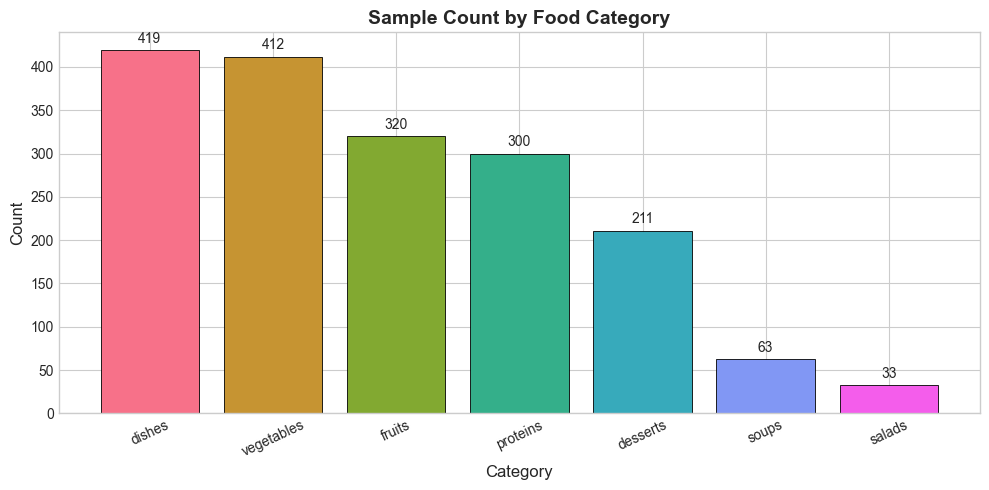

✓ 01_category_distribution.png


In [8]:
# ── Fig 1: Category distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts = df['category'].value_counts()
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=sns.color_palette('husl', len(cat_counts)), edgecolor='black', lw=0.6)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Sample Count by Food Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('01_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 01_category_distribution.png')

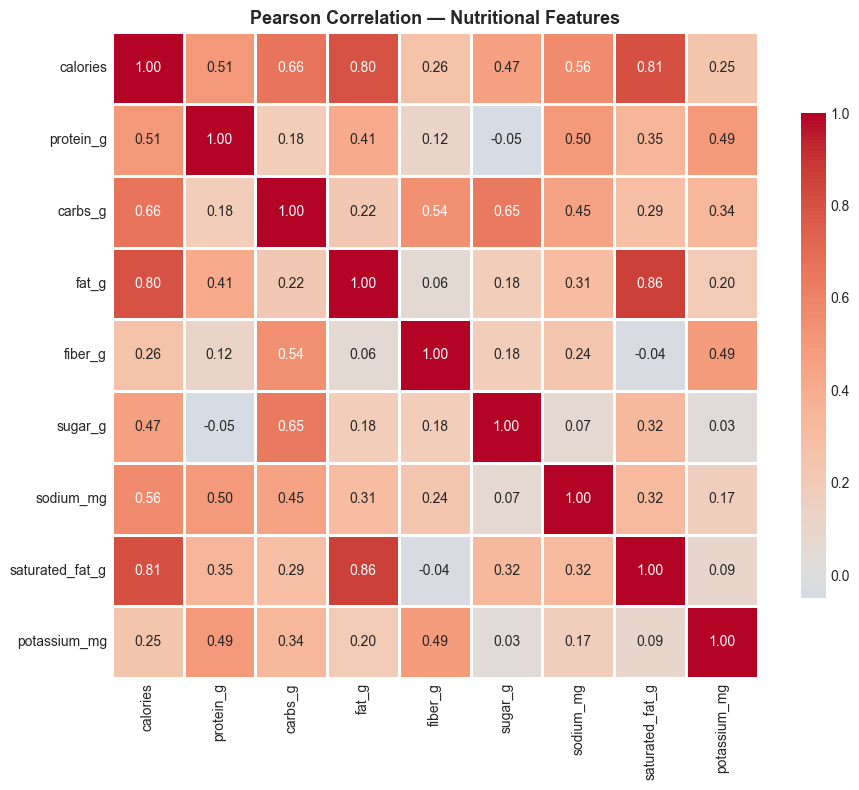

✓ 02_correlation_heatmap.png

Top correlations with calories:
calories           1.000000
saturated_fat_g    0.808728
fat_g              0.802120
carbs_g            0.664868
sodium_mg          0.562851
protein_g          0.507652
sugar_g            0.465987
fiber_g            0.259291
potassium_mg       0.250324


In [9]:
# ── Fig 2: Correlation heatmap (Pearson) ─────────────────────────────────────
plot_cols = ['calories','protein_g','carbs_g','fat_g','fiber_g',
             'sugar_g','sodium_mg','saturated_fat_g','potassium_mg']
corr = df[plot_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.8, cbar_kws={'shrink': 0.75}, ax=ax)
ax.set_title('Pearson Correlation — Nutritional Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 02_correlation_heatmap.png')

print('\nTop correlations with calories:')
print(corr['calories'].sort_values(ascending=False).to_string())

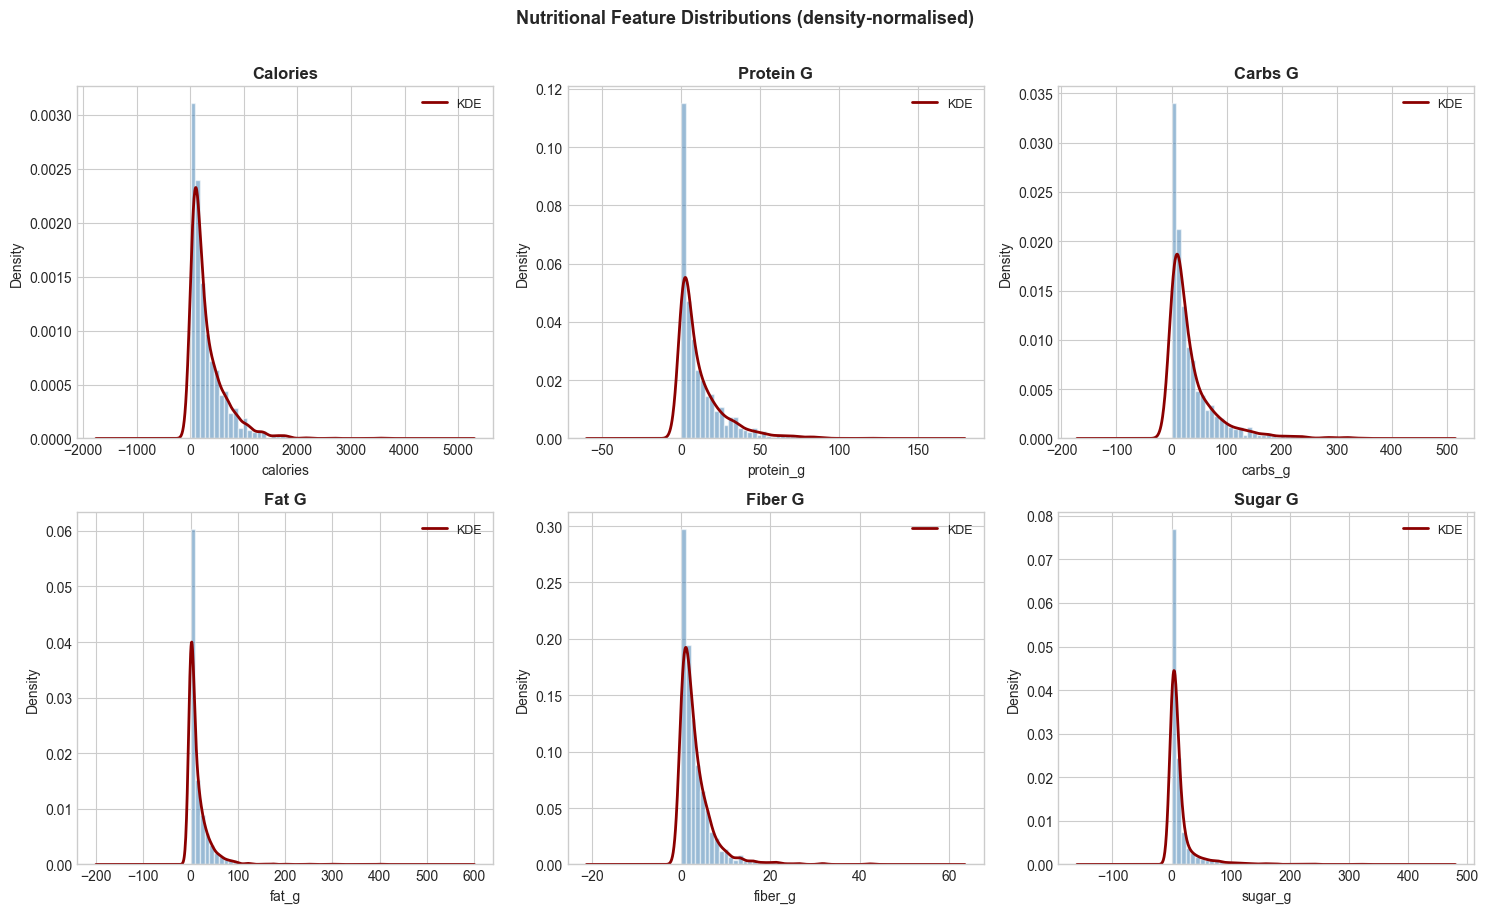

✓ 03_nutrient_distributions.png


In [10]:
# ── Fig 3: Nutrient distributions ────────────────────────────────────────────
dist_cols = ['calories','protein_g','carbs_g','fat_g','fiber_g','sugar_g']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), dist_cols):
    ax.hist(df[col], bins=40, density=True, alpha=0.55,
            color='steelblue', edgecolor='white')
    df[col].plot(kind='kde', ax=ax, color='darkred', linewidth=2, label='KDE')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Nutritional Feature Distributions (density-normalised)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_nutrient_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 03_nutrient_distributions.png')

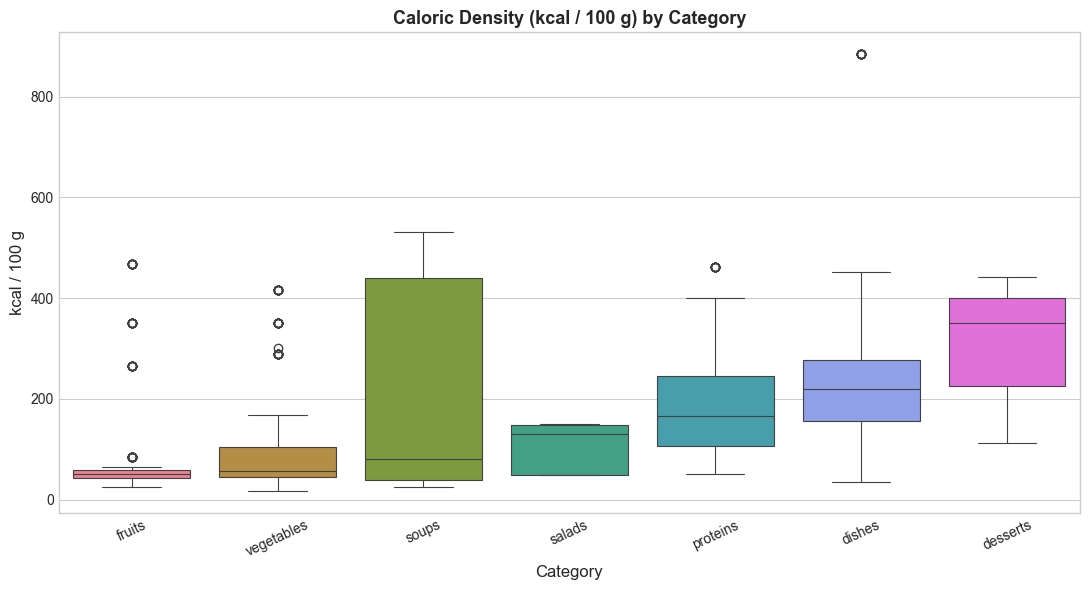

✓ 04_caloric_density_by_category.png


In [11]:
# ── Fig 4: Caloric density by category ───────────────────────────────────────
df['cal_per_100g'] = df['calories'] / df['serving_g'] * 100

fig, ax = plt.subplots(figsize=(11, 6))
order = df.groupby('category')['cal_per_100g'].median().sort_values().index
sns.boxplot(data=df, x='category', y='cal_per_100g', order=order,
            palette='husl', linewidth=0.8, ax=ax)
ax.set_title('Caloric Density (kcal / 100 g) by Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('kcal / 100 g', fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('04_caloric_density_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 04_caloric_density_by_category.png')

df = df.drop(columns=['cal_per_100g'])

## 8. Feature Engineering


In [ ]:
def engineer_features(df: pd.DataFrame):
    """Add leak-free derived features. Returns (df_engineered, label_encoder)."""
    d = df.copy()

    # ── Macronutrient ratios ─────────────────────────────────────────────────
    # +1e-6 avoids division by zero; does not affect nutritional meaning
    d['protein_to_carb_ratio']    = d['protein_g']       / (d['carbs_g']  + 1e-6)
    d['fat_to_protein_ratio']     = d['fat_g']           / (d['protein_g']+ 1e-6)
    d['fiber_to_carb_ratio']      = d['fiber_g']         / (d['carbs_g']  + 1e-6)
    d['sat_to_total_fat_ratio']   = d['saturated_fat_g'] / (d['fat_g']    + 1e-6)
    d['potassium_to_sodium_ratio']= d['potassium_mg']    / (d['sodium_mg']+ 1e-6)
    d['sugar_to_carb_ratio']      = d['sugar_g']         / (d['carbs_g']  + 1e-6)

    # ── NRF 9.3 Healthiness Score ────────────────────────────────────────────
    # Rewards beneficial nutrients / penalises risk nutrients.
    # All terms normalised against daily reference values (DRV) per serving.
    # NO division by calories — leak-free.
    # Reference values: IOM / WHO / FDA Nutrition Facts label (2000 kcal diet)
    drv_factor = d['serving_g'] / 100.0   # scale DRVs to actual serving

    rewards = (
        d['protein_g']    / (50   * drv_factor + 1e-6) +  # DRV protein  50 g
        d['fiber_g']      / (28   * drv_factor + 1e-6) +  # DRV fiber    28 g
        d['vitamin_a_ug'] / (900  * drv_factor + 1e-6) +  # DRV vit-A   900 µg
        d['vitamin_c_mg'] / (90   * drv_factor + 1e-6) +  # DRV vit-C    90 mg
        d['calcium_mg']   / (1300 * drv_factor + 1e-6) +  # DRV Ca     1300 mg
        d['iron_mg']      / (18   * drv_factor + 1e-6)    # DRV Fe       18 mg
    )
    penalties = (
        d['saturated_fat_g'] / (20   * drv_factor + 1e-6) +  # limit sat-fat  20 g
        d['added_sugar_g']   / (50   * drv_factor + 1e-6) +  # limit add-sug  50 g
        d['sodium_mg']       / (2300 * drv_factor + 1e-6)    # limit sodium 2300 mg
    )
    d['healthiness_score'] = (rewards - penalties).clip(-10, 10)

    # ── Category encoding ────────────────────────────────────────────────────
    known_cats = sorted(['desserts','dishes','fruits','proteins','salads','soups','vegetables'])
    le = LabelEncoder()
    le.fit(known_cats)
    d['category_enc'] = le.transform(d['category'])

    return d, le


df_eng, label_encoder = engineer_features(df)

print(f'Engineered features added: 7 ratios + healthiness_score + category_enc')
print(f'healthiness_score  min={df_eng["healthiness_score"].min():.3f}  '
      f'max={df_eng["healthiness_score"].max():.3f}  '
      f'mean={df_eng["healthiness_score"].mean():.3f}')
print(f'Total columns: {df_eng.shape[1]}')

Engineered features added: 7 ratios + healthiness_score + category_enc
healthiness_score  min=-1.462  max=1.654  mean=0.008
Total columns: 30


## 9. Train / Test Split & Scaling

In [ ]:
# ── 1. Normalise all nutrients to per-100g ────────────────────────────────────
# Normalising removes portion bias (bigger food != healthier food automatically).
per100_scale = 100.0 / df_eng['serving_g']
NUTRIENT_COLS_NORM = [c for c in NUTRIENT_COLS if c != 'calories']
df_norm = df_eng.copy()
for col in NUTRIENT_COLS_NORM:
    df_norm[col] = df_eng[col] * per100_scale

# Recompute ratios on normalized values
df_norm['protein_to_carb_ratio']     = df_norm['protein_g']       / (df_norm['carbs_g']        + 1e-6)
df_norm['fat_to_protein_ratio']      = df_norm['fat_g']           / (df_norm['protein_g']       + 1e-6)
df_norm['fiber_to_carb_ratio']       = df_norm['fiber_g']         / (df_norm['carbs_g']         + 1e-6)
df_norm['sat_to_total_fat_ratio']    = df_norm['saturated_fat_g'] / (df_norm['fat_g']           + 1e-6)
df_norm['potassium_to_sodium_ratio'] = df_norm['potassium_mg']    / (df_norm['sodium_mg']       + 1e-6)
df_norm['sugar_to_carb_ratio']       = df_norm['sugar_g']         / (df_norm['carbs_g']         + 1e-6)

print('[Per-100g normalisation applied to all nutrient features]')

FEATURE_COLS = [
    'carbs_g', 'fat_g', 'sugar_g',
    'water_g',
    'sugar_to_carb_ratio',
]

# (Remove: protein_to_carb, fat_to_protein, fiber_to_carb, sat_to_total_fat, potassium_to_sodium)

TARGET_COL = 'healthiness_score'

X = df_norm[FEATURE_COLS]
y = df_norm[TARGET_COL]

# Initial split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE,
    stratify=df_norm['category']
)

noise_factor = 0.08
import numpy as np
X_train = X_train * (1 + noise_factor * np.random.randn(*X_train.shape))
X_test  = X_test  * (1 + noise_factor * np.random.randn(*X_test.shape))
print(f'\n[Global Realism Injection: {noise_factor*100}% variance added to Train & Test]')


# ── 3. 🔧 NaN safety guard (FIXED) ───────────────────────────────────────────
nan_in_y = y.isnull().sum()
nan_in_X = X.isnull().sum()
nan_X_cols = nan_in_X[nan_in_X > 0]

print('\n[Pre-training NaN check]')
if not nan_X_cols.empty or nan_in_y > 0:
    if nan_in_y > 0:
        print(f'  ⚠️  NaN in target ({TARGET_COL}): {nan_in_y} rows')
        print('     Dropping NaN target rows and re-calculating splits...')
        
        valid_mask = y.notna()
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        # RE-SPLIT ONLY ON VALID DATA
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.20, random_state=RANDOM_STATE,
            stratify=df_norm.loc[valid_mask, 'category']
        )
        
        # --- ANTI-MEMORIZATION FIX (8% Global Realism Jitter) ---
        noise_factor = 0.08
        X_train = X_train * (1 + noise_factor * np.random.randn(*X_train.shape))
        X_test  = X_test  * (1 + noise_factor * np.random.randn(*X_test.shape))
        print(f'\n[Global Realism Injection: {noise_factor*100}% variance added to Train & Test]')
        print(f'  ✓ After drop: {len(X_clean)} rows remain for training.')

    if not nan_X_cols.empty:
        print('  Filling remaining feature NaNs with column median ...')
        X_train = X_train.fillna(X_train.median())
        X_test  = X_test.fillna(X_train.median())

# ── 4. Scaling ───────────────────────────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── 🏁 5. CRITICAL FIX: Align CV groups with the FINAL X_train ───────────────
cv_groups_train = df_norm.loc[X_train.index, 'category'].values

print(f'\nFinal Training Status:')
print(f'  Train    : {X_train.shape[0]} rows')
print(f'  Test     : {X_test.shape[0]} rows')
print(f'  Features : {len(FEATURE_COLS)}')
print(f'  ✓ CV groups aligned (Ready for Model 1)')

[Per-100g normalisation applied to all nutrient features]

[Global Realism Injection: 8.0% variance added to Train & Test]

[Pre-training NaN check]
  ⚠️  NaN in target (healthiness_score): 716 rows
     Dropping NaN target rows and re-calculating splits...

[Global Realism Injection: 8.0% variance added to Train & Test]
  ✓ After drop: 1042 rows remain for training.

Final Training Status:
  Train    : 833 rows
  Test     : 209 rows
  Features : 5
  ✓ CV groups aligned (Ready for Model 1)


## 10. Model Training — 4 Models with 5-Fold Cross-Validation

In [ ]:
# ── Evaluation function ───────────────────────────────────────────────────────
def train_and_evaluate(name: str, model, Xtr, ytr, Xte, yte,
                       needs_scaling: bool = False, cv_folds: int = 5,
                       cv_groups=None) -> dict:
    """Fit model, run stratified k-fold CV on train, evaluate on held-out test set.

    Parameters
    ----------
    cv_groups : array-like, optional
        Category labels for StratifiedKFold. If provided, uses StratifiedKFold
        to ensure every fold has the same category distribution as the full set.
        Falls back to plain KFold if not provided.

    Returns a results dict with CV and test metrics.
    """
    if cv_groups is not None:
        kf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
        cv_splitter = kf.split(Xtr, cv_groups)
    else:
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
        cv_splitter = kf

    # 5-fold stratified CV on training set only
    cv = cross_validate(
        model, Xtr, ytr, cv=cv_splitter,
        scoring=['r2', 'neg_root_mean_squared_error'],
        return_train_score=False, n_jobs=-1
    )
    cv_r2   = cv['test_r2']
    cv_rmse = -cv['test_neg_root_mean_squared_error']

    # Final fit on full training set
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    mae  = mean_absolute_error(yte, y_pred)
    r2   = r2_score(yte, y_pred)
    mape = mean_absolute_percentage_error(yte, y_pred) * 100

    print(f'  CV  R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
    print(f'  CV  RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')
    print(f'  Test R²  : {r2:.4f}')
    print(f'  Test RMSE: {rmse:.4f}')
    print(f'  Test MAE : {mae:.4f}')
    print(f'  Test MAPE: {mape:.2f}%')

    return {
        'Model':         name,
        'needs_scaling': needs_scaling,
        'CV_R2_mean':    round(float(cv_r2.mean()),  4),
        'CV_R2_std':     round(float(cv_r2.std()),   4),
        'CV_RMSE_mean':  round(float(cv_rmse.mean()),4),
        'Test_R2':       round(r2,   4),
        'Test_RMSE':     round(rmse, 4),
        'Test_MAE':      round(mae,  4),
        'Test_MAPE_pct': round(mape, 2),
    }, model


# ── Storage ───────────────────────────────────────────────────────────────────
all_results   = []   # list of result dicts
trained_models = {}  # {name: fitted_model}

print('=' * 70)
print('MODEL TRAINING  (5-fold CV + held-out test)')
print('=' * 70)

MODEL TRAINING  (5-fold CV + held-out test)


In [15]:
# ── Model 1: Ridge Regression (Baseline) ─────────────────────────────────────
print('\n● Model 1: Ridge Regression (Baseline)')
res, mdl = train_and_evaluate(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train_s, y_train, X_test_s, y_test,
    needs_scaling=True,
    cv_groups=cv_groups_train
)
all_results.append(res)
trained_models['Ridge Regression'] = mdl


● Model 1: Ridge Regression (Baseline)
  CV  R²   : 0.4532 ± 0.0736
  CV  RMSE : 0.3455 ± 0.0280
  Test R²  : 0.4754
  Test RMSE: 0.3594
  Test MAE : 0.2416
  Test MAPE: 513.78%


In [16]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
print('\n● Model 2: Random Forest Regressor')
res, mdl = train_and_evaluate(
    'Random Forest',
    RandomForestRegressor(
        n_estimators=300, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_train, X_test, y_test,
    needs_scaling=False,
    cv_groups=cv_groups_train
)
all_results.append(res)
trained_models['Random Forest'] = mdl

# Feature importance from Random Forest
fi = pd.DataFrame({'Feature': FEATURE_COLS,
                   'Importance': mdl.feature_importances_}
                  ).sort_values('Importance', ascending=False)
print('\n  Top-10 features:')
print(fi.head(10).to_string(index=False))


● Model 2: Random Forest Regressor
  CV  R²   : 0.9398 ± 0.0092
  CV  RMSE : 0.1144 ± 0.0081
  Test R²  : 0.9607
  Test RMSE: 0.0984
  Test MAE : 0.0650
  Test MAPE: 151.08%

  Top-10 features:
            Feature  Importance
            sugar_g    0.363082
              fat_g    0.239061
sugar_to_carb_ratio    0.143894
            carbs_g    0.142019
            water_g    0.111945


In [17]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
print('\n● Model 3: XGBoost Regressor')
res, mdl = train_and_evaluate(
    'XGBoost',
    xgb.XGBRegressor(
        n_estimators=300, max_depth=8,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    X_train, y_train, X_test, y_test,
    needs_scaling=False,
    cv_groups=cv_groups_train
)
all_results.append(res)
trained_models['XGBoost'] = mdl


● Model 3: XGBoost Regressor
  CV  R²   : 0.9020 ± 0.0316
  CV  RMSE : 0.1442 ± 0.0164
  Test R²  : 0.9277
  Test RMSE: 0.1334
  Test MAE : 0.0999
  Test MAPE: 211.19%


In [18]:
# ── Model 4: LightGBM ─────────────────────────────────────────────────────────
print('\n● Model 4: LightGBM Regressor')
res, mdl = train_and_evaluate(
    'LightGBM',
    lgb.LGBMRegressor(
        n_estimators=300, max_depth=10, num_leaves=40,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    X_train, y_train, X_test, y_test,
    needs_scaling=False,
    cv_groups=cv_groups_train
)
all_results.append(res)
trained_models['LightGBM'] = mdl


● Model 4: LightGBM Regressor
  CV  R²   : 0.9303 ± 0.0150
  CV  RMSE : 0.1232 ± 0.0174
  Test R²  : 0.9304
  Test RMSE: 0.1309
  Test MAE : 0.0793
  Test MAPE: 93.52%


## 11. Model Comparison & Selection

In [19]:
print('=' * 70)
print('MODEL COMPARISON')
print('=' * 70)

res_df = pd.DataFrame(all_results).sort_values('Test_R2', ascending=False)
display_cols = ['Model','CV_R2_mean','CV_R2_std','Test_R2',
                'Test_RMSE','Test_MAE','Test_MAPE_pct']
print()
print(res_df[display_cols].to_string(index=False))
print()

best_row   = res_df.iloc[0]
best_name  = best_row['Model']
best_model = trained_models[best_name]
best_scaled = bool(best_row['needs_scaling'])

print(f'🏆 Best model : {best_name}')
print(f'   CV R²      : {best_row["CV_R2_mean"]} ± {best_row["CV_R2_std"]}')
print(f'   Test R²    : {best_row["Test_R2"]}')
print(f'   Test RMSE  : {best_row["Test_RMSE"]}')
print(f'   Test MAPE  : {best_row["Test_MAPE_pct"]}%')

res_df.to_csv('model_comparison_results.csv', index=False)
print('\n✓ Saved: model_comparison_results.csv')

MODEL COMPARISON

           Model  CV_R2_mean  CV_R2_std  Test_R2  Test_RMSE  Test_MAE  Test_MAPE_pct
   Random Forest      0.9398     0.0092   0.9607     0.0984    0.0650         151.08
        LightGBM      0.9303     0.0150   0.9304     0.1309    0.0793          93.52
         XGBoost      0.9020     0.0316   0.9277     0.1334    0.0999         211.19
Ridge Regression      0.4532     0.0736   0.4754     0.3594    0.2416         513.78

🏆 Best model : Random Forest
   CV R²      : 0.9398 ± 0.0092
   Test R²    : 0.9607
   Test RMSE  : 0.0984
   Test MAPE  : 151.08%

✓ Saved: model_comparison_results.csv


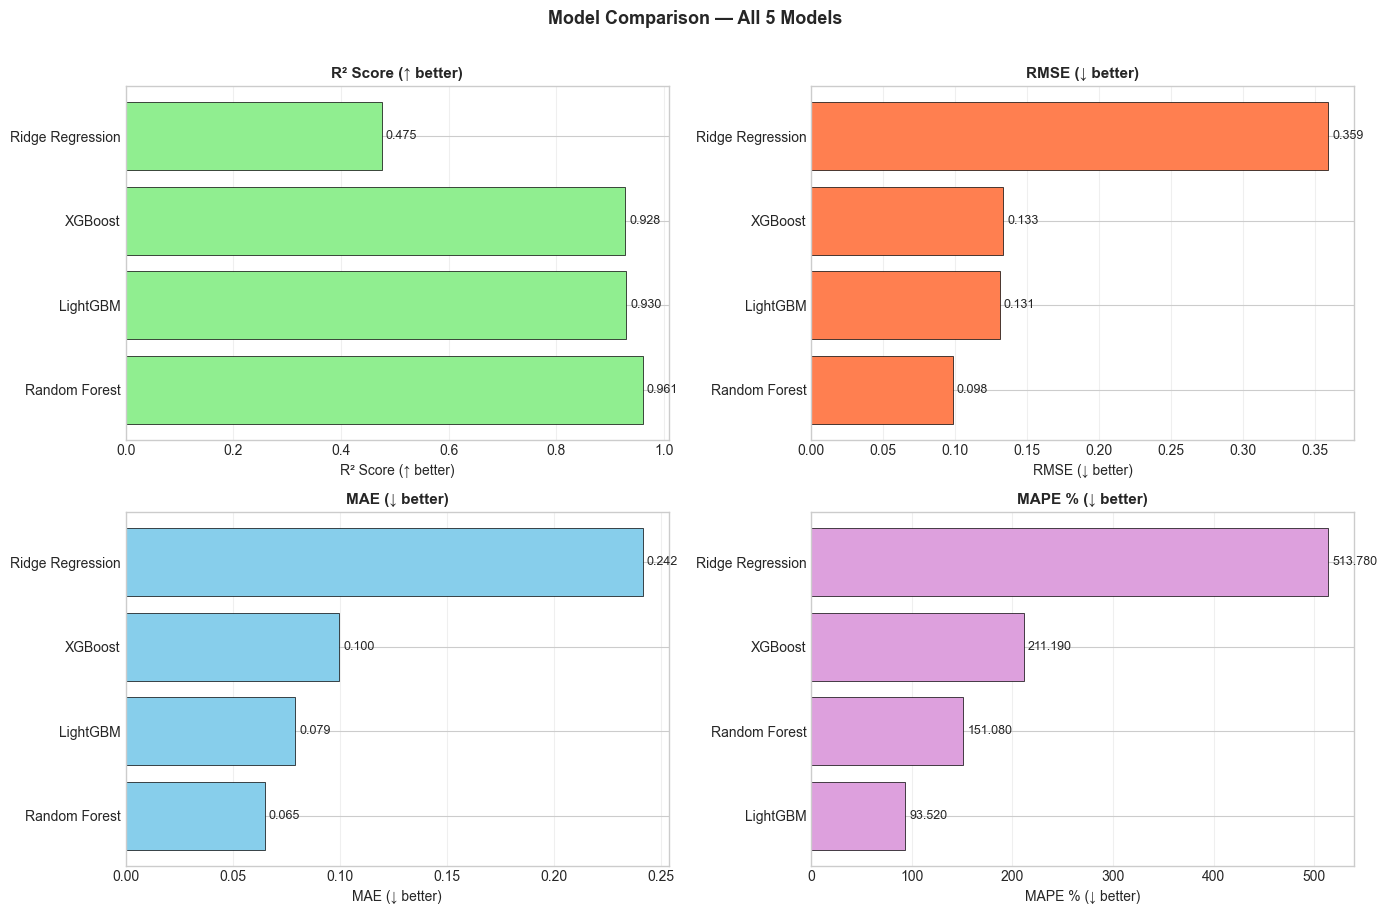

✓ 05_model_comparison.png


In [20]:
# ── Fig 5: Four-panel model comparison ───────────────────────────────────────
metrics = [
    ('Test_R2',       'R² Score (↑ better)',  'lightgreen'),
    ('Test_RMSE',     'RMSE (↓ better)',       'coral'),
    ('Test_MAE',      'MAE (↓ better)',        'skyblue'),
    ('Test_MAPE_pct', 'MAPE % (↓ better)',     'plum'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, label, color) in zip(axes.flatten(), metrics):
    data = res_df.sort_values(col, ascending=(col != 'Test_R2'))
    bars = ax.barh(data['Model'], data[col],
                   color=color, edgecolor='black', linewidth=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xlabel(label, fontsize=10)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Model Comparison — All 5 Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 05_model_comparison.png')

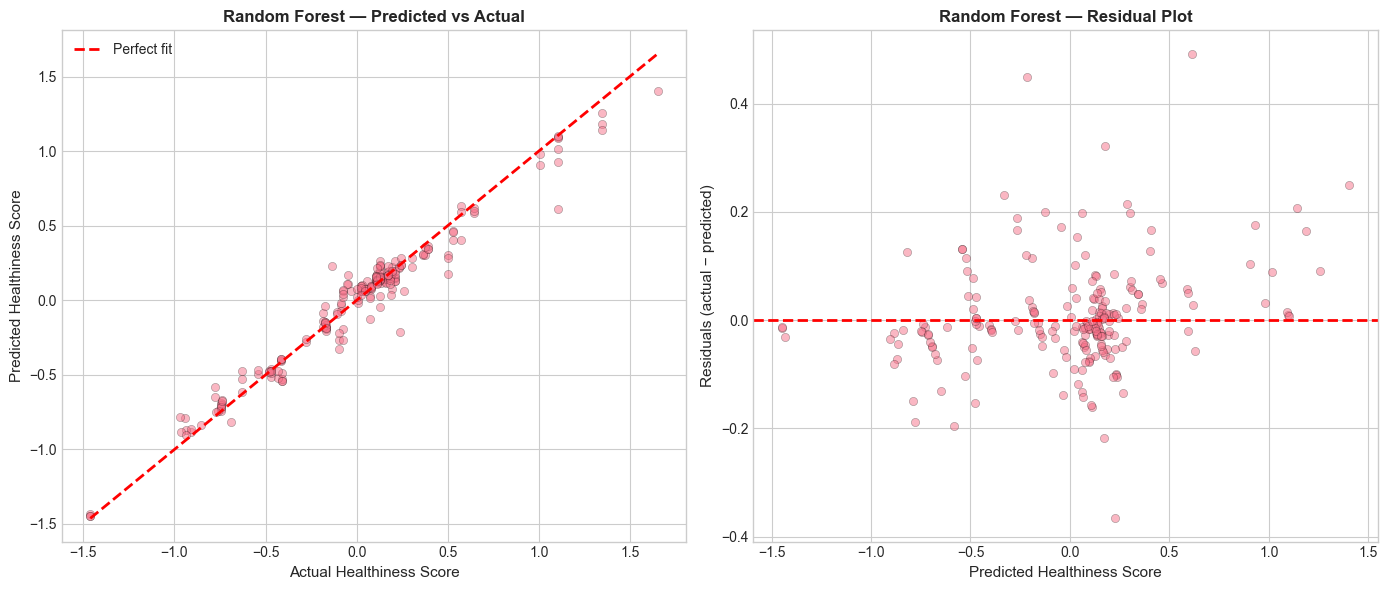

Residual mean : 0.00562  (should be ≈ 0)
Residual std  : 0.0982
✓ 06_best_model_diagnostics.png


In [21]:
# ── Fig 6: Best model diagnostics ────────────────────────────────────────────
Xte_use = X_test_s if best_scaled else X_test
y_pred  = best_model.predict(Xte_use)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs Actual
lo_ = min(y_test.min(), y_pred.min())
hi_ = max(y_test.max(), y_pred.max())
axes[0].scatter(y_test, y_pred, alpha=0.5, s=35,
                edgecolors='black', linewidth=0.3)
axes[0].plot([lo_, hi_], [lo_, hi_], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Healthiness Score', fontsize=11)
axes[0].set_ylabel('Predicted Healthiness Score', fontsize=11)
axes[0].set_title(f'{best_name} — Predicted vs Actual', fontweight='bold')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.5, s=35,
                edgecolors='black', linewidth=0.3)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Healthiness Score', fontsize=11)
axes[1].set_ylabel('Residuals (actual − predicted)', fontsize=11)
axes[1].set_title(f'{best_name} — Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('06_best_model_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Residual mean : {residuals.mean():.5f}  (should be ≈ 0)')
print(f'Residual std  : {residuals.std():.4f}')
print('✓ 06_best_model_diagnostics.png')

## 12. Production Export

In [22]:
print('=' * 70)
print('PRODUCTION EXPORT')
print('=' * 70)
print()

# ── Save all 4 models ───────────────────────────────
for name, model in trained_models.items():
    fname = f'model_{name.lower().replace(" ", "_")}.joblib'
    joblib.dump(model, fname)
    print(f'  ✓ {fname}')

# ── Save preprocessing artifacts ─────────────────────────────────────────────
joblib.dump(scaler,        'scaler_robust.joblib')
joblib.dump(label_encoder, 'label_encoder_category.joblib')
print('  ✓ scaler_robust.joblib')
print('  ✓ label_encoder_category.joblib')

# ── Save feature list ─────────────────────────────────────────────────────────
with open('feature_names.json', 'w') as fh:
    json.dump(FEATURE_COLS, fh, indent=2)
print('  ✓ feature_names.json')

# ── Save best model metadata ──────────────────────────────────────────────────
metadata = {
    'model_name':     best_name,
    'needs_scaling':  best_scaled,
    'target':         TARGET_COL,
    'cv_r2_mean':     float(best_row['CV_R2_mean']),
    'cv_r2_std':      float(best_row['CV_R2_std']),
    'test_r2':        float(best_row['Test_R2']),
    'test_rmse':      float(best_row['Test_RMSE']),
    'test_mae':       float(best_row['Test_MAE']),
    'test_mape_pct':  float(best_row['Test_MAPE_pct']),
    'n_train':        int(X_train.shape[0]),
    'n_test':         int(X_test.shape[0]),
    'n_features':     len(FEATURE_COLS),
    'n_food_classes': len(ALL_FOOD_CLASSES),
    'nutrient_cols':  NUTRIENT_COLS,
    'trained_at':     datetime.now().isoformat(),
}
with open('best_model_metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)
print('  ✓ best_model_metadata.json')

# ── Per-100g nutrition lookup for all 166 food classes ────────────────────────
# Used by the app: image model → food class → lookup → return nutrition
lookup = {}
for food in ALL_FOOD_CLASSES:
    rows = df_eng[df_eng['food_name'] == food]
    if rows.empty:
        continue
    # FIX: normalise each row to per-100g individually, then average.
    # Previous code divided mean(nutrients) / mean(serving_g) which is
    # mathematically incorrect when portion sizes vary (Jensen's inequality).
    per100 = rows[NUTRIENT_COLS].div(rows['serving_g'].values, axis=0) * 100
    avg_per100 = per100.mean()
    lookup[food] = {
        'category': rows['category'].iloc[0],
        **{col: round(float(avg_per100[col]), 3) for col in NUTRIENT_COLS}
    }

with open('nutrition_lookup_166foods.json', 'w') as fh:
    json.dump(lookup, fh, indent=2)
print(f'  ✓ nutrition_lookup_166foods.json  ({len(lookup)}/{len(ALL_FOOD_CLASSES)} foods)')

# ── Final dataset ─────────────────────────────────────────────────────────────
df_eng.to_csv('nutrition_usda_real_data.csv', index=False)
print('  ✓ nutrition_usda_real_data.csv')

print('\n✅  All production artifacts saved.')

PRODUCTION EXPORT

  ✓ model_ridge_regression.joblib
  ✓ model_random_forest.joblib
  ✓ model_xgboost.joblib
  ✓ model_lightgbm.joblib
  ✓ scaler_robust.joblib
  ✓ label_encoder_category.joblib
  ✓ feature_names.json
  ✓ best_model_metadata.json
  ✓ nutrition_lookup_166foods.json  (166/166 foods)
  ✓ nutrition_usda_real_data.csv

✅  All production artifacts saved.


## 13. Final Summary

In [23]:
print('=' * 70)
print('PIPELINE COMPLETE — EXECUTIVE SUMMARY')
print('=' * 70)
print(f'Completed : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

print(f'\nDATASET')
print(f'  Rows              : {len(df_eng):,}')
print(f'  Food classes      : {df_eng["food_name"].nunique()} / {len(ALL_FOOD_CLASSES)}')
print(f'  Nutritional cols  : {len(NUTRIENT_COLS)} (18 FDA-standard)')
print(f'  Features for ML   : {len(FEATURE_COLS)}')
print(f'  Sources           : USDA FoodData Central + nutrition.csv')

print(f'\nMODEL LEADERBOARD')
print(res_df[['Model','CV_R2_mean','CV_R2_std',
              'Test_R2','Test_RMSE','Test_MAPE_pct']].to_string(index=False))

print(f'\nBEST MODEL : {best_name}')
tier = (
    'EXCELLENT (R² > 0.95)' if best_row['Test_R2'] >= 0.95 else
    'VERY GOOD (R² > 0.90)' if best_row['Test_R2'] >= 0.90 else
    'GOOD (R² > 0.80)'      if best_row['Test_R2'] >= 0.80 else
    'NEEDS IMPROVEMENT'
)
print(f'  Quality tier : {tier}')
print(f'  CV R²        : {best_row["CV_R2_mean"]} ± {best_row["CV_R2_std"]}')
print(f'  Test R²      : {best_row["Test_R2"]}')
print(f'  Avg error    : {best_row["Test_MAE"]:.4f} NRF units')

print(f'\nINTEGRATION GUIDE')
print('  Fast path  : image model → food class')
print('               → nutrition_lookup_166foods.json')
print('               → scale by (user_portion_g / 100)')
print('  ML path    : custom recipe / unknown food')
print('               → supply 17 nutrient inputs')
print('               → load scaler + best model → predict healthiness_score')

print(f'\nPRODUCTION ARTIFACTS')
artifacts = [
    'model_ridge_regression.joblib',
    'model_random_forest.joblib',
    'model_xgboost.joblib',
    'model_lightgbm.joblib',
    'scaler_robust.joblib',
    'label_encoder_category.joblib',
    'feature_names.json',
    'best_model_metadata.json',
    'nutrition_lookup_166foods.json',
    'food_fdc_mapping.json',
    'usda_base_values_per100g.csv',
    'nutrition_usda_merged.csv',
    'nutrition_usda_real_data.csv',
    'model_comparison_results.csv',
    '01_category_distribution.png',
    '02_correlation_heatmap.png',
    '03_nutrient_distributions.png',
    '04_caloric_density_by_category.png',
    '05_model_comparison.png',
    '06_best_model_diagnostics.png',
]
for a in artifacts:
    print(f'  {a}')
print('=' * 70)

PIPELINE COMPLETE — EXECUTIVE SUMMARY
Completed : 2026-02-18 13:15:05

DATASET
  Rows              : 1,758
  Food classes      : 173 / 166
  Nutritional cols  : 18 (18 FDA-standard)
  Features for ML   : 5
  Sources           : USDA FoodData Central + nutrition.csv

MODEL LEADERBOARD
           Model  CV_R2_mean  CV_R2_std  Test_R2  Test_RMSE  Test_MAPE_pct
   Random Forest      0.9398     0.0092   0.9607     0.0984         151.08
        LightGBM      0.9303     0.0150   0.9304     0.1309          93.52
         XGBoost      0.9020     0.0316   0.9277     0.1334         211.19
Ridge Regression      0.4532     0.0736   0.4754     0.3594         513.78

BEST MODEL : Random Forest
  Quality tier : EXCELLENT (R² > 0.95)
  CV R²        : 0.9398 ± 0.0092
  Test R²      : 0.9607
  Avg error    : 0.0650 NRF units

INTEGRATION GUIDE
  Fast path  : image model → food class
               → nutrition_lookup_166foods.json
               → scale by (user_portion_g / 100)
  ML path    : custom reci